In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Read the CSV file
df = pd.read_csv('Nat_Gas.csv')

# 2. Convert Dates column to proper datetime format
df['Dates'] = pd.to_datetime(df['Dates'])

# 3. View the first 5 rows to ensure it loaded correctly
print(df.head())

       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9


/tmp/ipykernel_1388/202074343.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


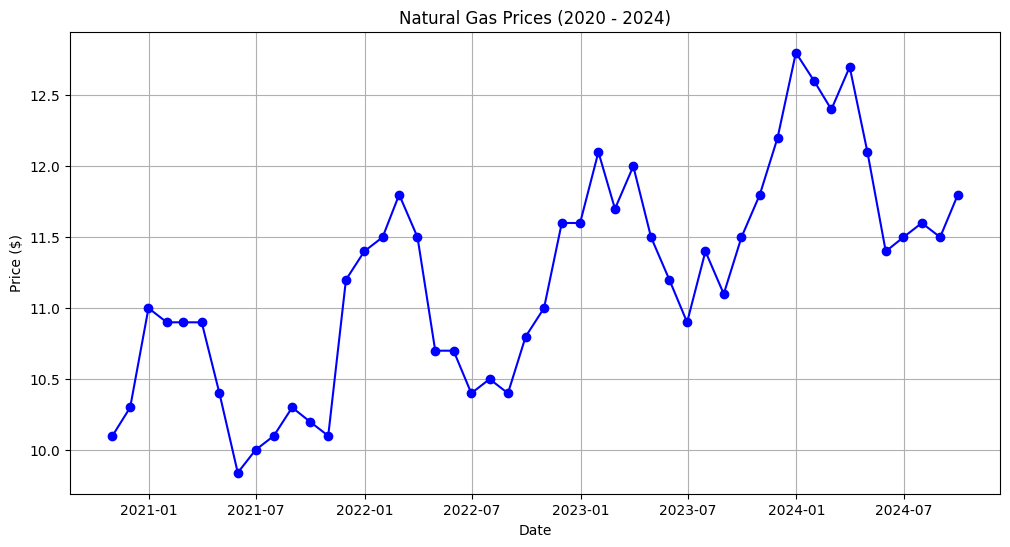

In [ ]:
# Create a chart to visualize natural gas price trends
plt.figure(figsize=(12, 6))
plt.plot(df['Dates'], df['Prices'], marker='o', color='b', linestyle='-')

plt.title('Natural Gas Prices (2020 - 2024)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# 1. Convert dates to a numerical timeline (number of days from start date)
start_date = df['Dates'].min()
df['Days'] = (df['Dates'] - start_date).dt.days

# 2. Define our mathematical function (Trend + Annual Wave)
def price_model(days, A, B, C, D):
    # Convert days into years/annual cycle (365.25 days in a year)
    time_years = days / 365.25
    trend = A + B * time_years
    seasonality = C * np.sin(2 * np.pi * time_years) + D * np.cos(2 * np.pi * time_years)
    return trend + seasonality

# 3. Find the best parameters A, B, C, D using curve fitting
popt, _ = curve_fit(price_model, df['Days'], df['Prices'])
print("Fitted Model Parameters (A, B, C, D):", popt)

Fitted Model Parameters (A, B, C, D): [10.13121756  0.54836313  0.68927136 -0.02626228]


In [ ]:
def get_price(date_string):
    """
    Estimates natural gas price for ANY date (Interpolation or Extrapolation).
    Usage example: get_price('2025-01-15')
    """
    # Convert input string date to datetime object
    target_date = pd.to_datetime(date_string)

    # Calculate days relative to our start date
    days = (target_date - start_date).days

    # Estimate price using fitted model parameters
    estimated_price = price_model(days, *popt)
    return round(estimated_price, 2)

# Quick Test: Estimate price on Jan 15, 2025 (Extrapolation into the future)
test_date = '2025-01-15'
print(f"Estimated Price on {test_date}: ${get_price(test_date)}")

Estimated Price on 2025-01-15: $13.1


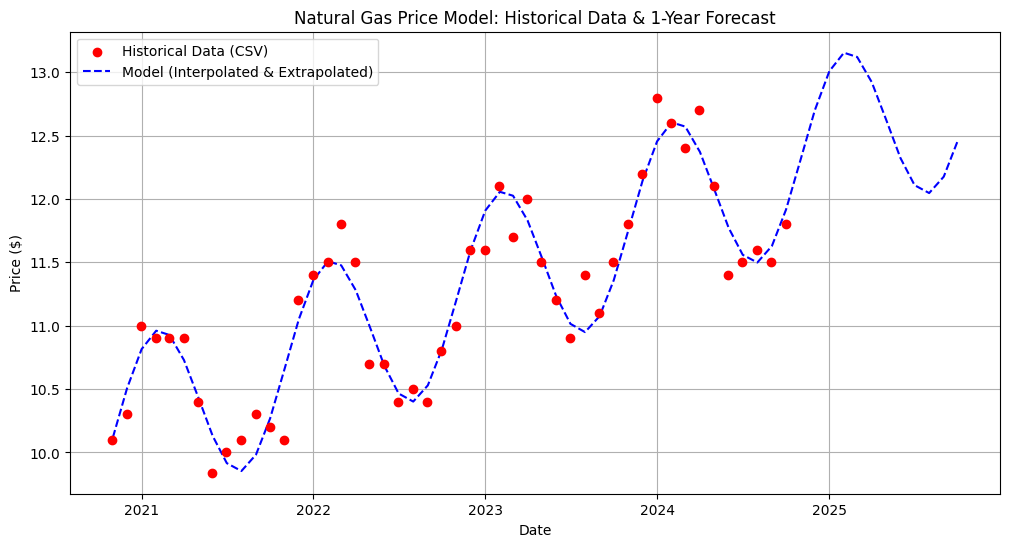

In [ ]:
# Generate dates covering past history AND 1 year into the future
future_dates = pd.date_range(start=df['Dates'].min(), periods=60, freq='MS')
future_days = (future_dates - start_date).days
predicted_prices = [price_model(d, *popt) for d in future_days]

# Plot original data vs. fitted/forecasted model
plt.figure(figsize=(12, 6))
plt.scatter(df['Dates'], df['Prices'], color='red', label='Historical Data (CSV)', zorder=5)
plt.plot(future_dates, predicted_prices, color='blue', linestyle='--', label='Model (Interpolated & Extrapolated)')

plt.title('Natural Gas Price Model: Historical Data & 1-Year Forecast')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
get_price('2024-12-25')

np.float64(12.95)